In [1]:
from pymongo import MongoClient
from dotenv import load_dotenv
import os 

load_dotenv()

MONGO_URL = os.getenv("MONGO_URL")

client = MongoClient(MONGO_URL)

#Create database
db = client["quant_insignt"]

#Create collection
collection = db["stock_data"]

print("MongoDB Altaas connected successfully !")


MongoDB Altaas connected successfully !


In [2]:
print(collection)

Collection(Database(MongoClient(host=['ac-ipac6kf-shard-00-01.rjb3wel.mongodb.net:27017', 'ac-ipac6kf-shard-00-00.rjb3wel.mongodb.net:27017', 'ac-ipac6kf-shard-00-02.rjb3wel.mongodb.net:27017'], document_class=dict, tz_aware=False, connect=True, appname='webDev', authsource='admin', replicaset='atlas-jxu2l3-shard-0', tls=True), 'quant_insignt'), 'stock_data')


In [3]:
symbols = ["AAPL","HSBC","HON", "HEPS", "HERO"]
import pandas as pd

all_data = []

for symbol in symbols:
    data =  list(collection.find({"symbol": symbol }))
    df = pd.DataFrame(data)

    df["date"] = pd.to_datetime(df["date"])
    df = df.sort_values(by = "date", ascending=False )

    df = df[["return","date"]]

    df.rename(columns={"return" : symbol }, inplace=True)

    all_data.append(df)

final_data = all_data[0]

for df in all_data[1:]:
    final_data = pd.merge(final_data, df, on="date", how="inner")

final_data.set_index("date", inplace= True)

print(final_data)

              AAPL    HSBC     HON    HEPS    HERO
date                                              
2026-03-30  0.0000 -0.0381 -0.0113 -0.0038 -0.0276
2026-03-27  0.0000 -0.0020 -0.0016  0.0000  0.0064
2026-03-26  0.0164  0.0056  0.0092  0.0077 -0.0071
2026-03-25 -0.0011  0.0200  0.0028  0.0190  0.0160
2026-03-24 -0.0039 -0.0240 -0.0187 -0.0037 -0.0035
...            ...     ...     ...     ...     ...
2025-11-11  0.0065 -0.0131 -0.0059 -0.0043 -0.0025
2025-11-10 -0.0211 -0.0068 -0.0217  0.0000 -0.0050
2025-11-07 -0.0036 -0.0107 -0.0102 -0.0086 -0.0106
2025-11-06  0.0048  0.0104  0.0095  0.0000  0.0060
2025-11-05  0.0014 -0.0151  0.0058  0.0260  0.0097

[99 rows x 5 columns]


In [4]:
corr_matrix = round(final_data.corr(),2)
print(corr_matrix)

      AAPL  HSBC   HON  HEPS  HERO
AAPL  1.00  0.46  0.23  0.10  0.21
HSBC  0.46  1.00  0.42  0.10  0.47
HON   0.23  0.42  1.00  0.17  0.26
HEPS  0.10  0.10  0.17  1.00  0.12
HERO  0.21  0.47  0.26  0.12  1.00


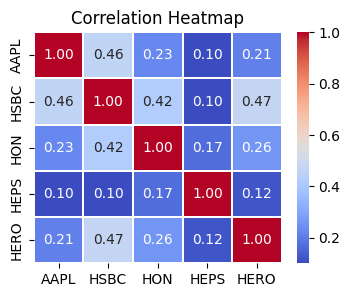

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(4,3))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap=,
    fmt=".2f",
    linewidths=0.2
)

plt.title("Correlation Heatmap")
plt.show()

In [14]:
corr_matrix.values.tolist()

[[1.0,
  0.4590221434355859,
  0.23411822762138426,
  0.09560954250189224,
  0.20627126409971522],
 [0.4590221434355859,
  1.0,
  0.42132805579402804,
  0.09883191389571164,
  0.47313879521564844],
 [0.23411822762138426,
  0.42132805579402804,
  1.0,
  0.17418488837569132,
  0.26196987245641057],
 [0.09560954250189224,
  0.09883191389571164,
  0.17418488837569132,
  1.0,
  0.12288502582464829],
 [0.20627126409971522,
  0.47313879521564844,
  0.26196987245641057,
  0.12288502582464829,
  1.0]]